# Credit Card Fraud Detection with Imbalanced Learning and Threshold Optimization

## Problem Definition

Fraud detection is one of the most important real-world applications of machine learning in financial services. The objective is to identify rare fraudulent transactions among a very large number of legitimate ones. This makes the problem especially challenging because the dataset is **highly imbalanced**: fraudulent transactions account for only a tiny fraction of all observations.

In this type of setting, conventional evaluation choices can be misleading. A model may achieve extremely high accuracy simply by predicting nearly all transactions as legitimate, while still failing to detect actual fraud. For that reason, fraud detection requires a more careful modeling strategy and stronger emphasis on metrics such as **precision, recall, F1-score, ROC-AUC, and PR-AUC**.

## Project Objectives

In this notebook, I will:

- inspect the structure and quality of the dataset
- analyze the degree of class imbalance
- perform focused exploratory data analysis
- build baseline classification models
- apply imbalance-aware techniques such as class weighting and SMOTE
- compare models using appropriate evaluation metrics
- optimize the decision threshold for the best-performing model
- provide a practical recommendation based on the precision–recall trade-off

## Why This Project Matters

This project reflects a realistic machine learning scenario in which **business-aware model evaluation matters more than raw accuracy**. It demonstrates how imbalance-aware methods and threshold tuning can improve the practical usefulness of a fraud detection system in real-world decision-making.

> **Note:** Figures generated throughout this notebook are automatically exported to the `figures/` directory for reuse in the project README and repository documentation.

## Environment Setup and Imports

This section prepares the notebook environment, connects the project workspace in Google Drive, and imports the required libraries for data analysis, visualization, machine learning, and imbalance-aware modeling.

The project relies primarily on:

- `pandas` and `numpy` for data handling
- `matplotlib` for visualization
- `scikit-learn` for modeling and evaluation
- `imbalanced-learn` for techniques specifically designed for imbalanced classification

To ensure reproducibility, a fixed random seed is used throughout the notebook.

In [14]:
# Google Drive / project setup
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/ML Portfolio/credit-card-fraud-detection-imbalanced-learning"
os.chdir(PROJECT_PATH)

print("Working directory:", os.getcwd())
print("Data folder available:", os.path.exists("data"))
print("Figures folder available:", os.path.exists("figures"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/ML Portfolio/credit-card-fraud-detection-imbalanced-learning
Data folder available: True
Figures folder available: True


In [15]:
# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    ConfusionMatrixDisplay
)

# Preprocessing and pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Imbalanced learning tools
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

# Notebook display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Figures export directory
FIGURES_PATH = "figures"
os.makedirs(FIGURES_PATH, exist_ok=True)

print("Environment configured successfully.")
print(f"Figures will be saved to: {FIGURES_PATH}")

Environment configured successfully.
Figures will be saved to: figures


### Environment Setup Summary

The notebook environment has been configured successfully, and the project workspace in Google Drive is now active.

All required libraries for data analysis, visualization, machine learning, and imbalance-aware modeling have been imported. In addition, the `figures/` directory has been initialized so that all key visualizations generated throughout the notebook can be exported automatically for use in the project repository and README.

A fixed random seed (`RANDOM_STATE = 42`) is used to ensure reproducibility. This helps guarantee that data splits and model training results remain consistent across runs.

## Data Loading and Initial Inspection

In this section, the dataset is loaded and its basic structure is inspected. Understanding the size, features, and general layout of the dataset is an essential first step before performing exploratory analysis or building machine learning models.

The dataset used in this project contains anonymized credit card transactions, where the target variable indicates whether a transaction is fraudulent or legitimate.

In [16]:
# Load dataset
df = pd.read_csv("data/creditcard.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [12]:
# Dataset dimensions
print("Dataset shape:", df.shape)

Dataset shape: (284807, 31)


In [17]:
# Preview the first rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [18]:
# Display column names
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [19]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [20]:
# Summary statistics
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,94813.8596,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,88.3496,0.0017
std,47488.1460,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,1.0888,1.0207,0.9992,0.9953,0.9586,0.9153,0.8763,0.8493,0.8382,0.8140,0.7709,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301,250.1201,0.0415
min,0.0000,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,-24.5883,-4.7975,-18.6837,-5.7919,-19.2143,-4.4989,-14.1299,-25.1628,-9.4987,-7.2135,-54.4977,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301,0.0000,0.0000
25%,54201.5000,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,-0.5354,-0.7625,-0.4056,-0.6485,-0.4256,-0.5829,-0.4680,-0.4837,-0.4988,-0.4563,-0.2117,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530,5.6000,0.0000
50%,84692.0000,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,-0.0929,-0.0328,0.1400,-0.0136,0.0506,0.0481,0.0664,-0.0657,-0.0036,0.0037,-0.0625,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112,22.0000,0.0000
75%,139320.5000,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,0.4539,0.7396,0.6182,0.6625,0.4931,0.6488,0.5233,0.3997,0.5008,0.4589,0.1330,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783,77.1650,0.0000
max,172792.0000,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,23.7451,12.0189,7.8484,7.1269,10.5268,8.8777,17.3151,9.2535,5.0411,5.5920,39.4209,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478,25691.1600,1.0000


### Initial Dataset Observations

The dataset contains **284,807 credit card transactions** with **31 columns**, including 30 numerical features and one target variable (`Class`) indicating whether a transaction is fraudulent or legitimate.

Several key observations emerge from the initial inspection:

- The dataset consists entirely of **numerical variables**, which simplifies preprocessing and allows most machine learning models to be applied directly without categorical encoding.

- Features **V1–V28** are anonymized variables created through a **Principal Component Analysis (PCA) transformation**. This anonymization preserves useful statistical information while protecting sensitive transaction data.

- The **`Amount`** feature represents the monetary value of each transaction.

- The **`Time`** feature measures the time elapsed (in seconds) between the current transaction and the first transaction in the dataset.

- The target variable **`Class`** is binary:
  - `0` → legitimate transaction
  - `1` → fraudulent transaction

- All columns contain **284,807 non-null values**, indicating that the dataset does **not contain missing data**, which simplifies the data preparation stage.

- The PCA-transformed features have **means close to zero and similar standard deviations**, which is expected when PCA is applied to normalized data.

At this stage, the dataset appears structurally clean and suitable for further analysis. The next step is to examine the **data quality and integrity**, including checks for duplicate records and a closer look at the distribution of the target variable.

## Data Quality Check

Before proceeding to exploratory analysis and modeling, it is essential to verify the integrity of the dataset. Data quality issues such as missing values or duplicate records can introduce bias or distort model performance if left unaddressed.

In this section, the dataset is examined for:

- missing values across all features
- duplicate transaction records

Confirming data integrity at this stage ensures that the dataset is suitable for reliable machine learning analysis.

In [21]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values per column:")
display(missing_values[missing_values > 0])

print("\nTotal missing values in dataset:", missing_values.sum())

Missing values per column:


,0



Total missing values in dataset: 0


In [22]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 1081


In [23]:
# Remove duplicate rows if present
if duplicate_rows > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

print("New dataset shape:", df.shape)

Duplicates removed.
New dataset shape: (283726, 31)


### Data Quality Assessment

A data quality inspection was performed to ensure the reliability of the dataset before proceeding with exploratory analysis and modeling.

The missing value check confirms that **no missing values are present across any of the dataset's features**, meaning the dataset is complete and does not require any imputation or correction for incomplete records.

However, the inspection revealed **1,081 duplicate transaction rows**. Duplicate records can introduce bias in machine learning models because repeated observations may disproportionately influence the learning process.

To ensure that each transaction represents a unique observation, duplicate rows were removed from the dataset. After this cleaning step, the dataset contains **283,726 transactions** while maintaining the same feature structure of **30 numerical variables plus the target variable (`Class`)**.

With the dataset now verified and cleaned, it is ready for exploratory analysis. The next step is to investigate the **distribution of the target variable**, which will reveal the extent of class imbalance in the fraud detection problem.

## Target Class Imbalance Analysis

Fraud detection datasets are typically **highly imbalanced**, meaning that fraudulent transactions represent only a very small fraction of all observations.

Understanding the distribution of the target variable is crucial before building machine learning models. In highly imbalanced classification problems, standard metrics such as accuracy can be misleading. A model that predicts every transaction as legitimate could still achieve very high accuracy while completely failing to detect fraud.

In this section, the distribution of fraudulent and legitimate transactions is examined both numerically and visually.

In [24]:
# Count transactions by class
class_counts = df["Class"].value_counts()

print("Transaction counts by class:")
display(class_counts)

Transaction counts by class:


,count
Class,
0,283253
1,473


In [25]:
# Compute class percentages
class_percentages = df["Class"].value_counts(normalize=True) * 100

print("Class percentages:")
display(class_percentages)

Class percentages:


,proportion
Class,
0,99.8333
1,0.1667


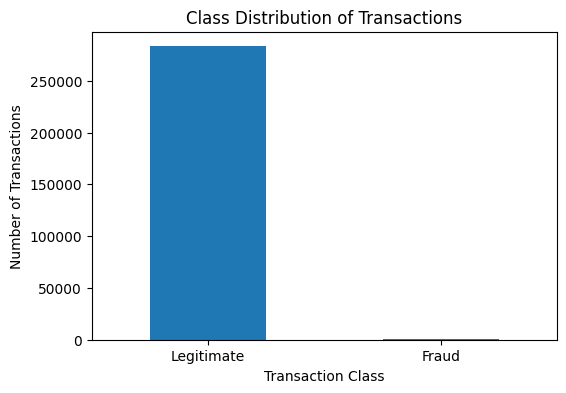

In [26]:
# Plot class distribution
plt.figure(figsize=(6, 4))

class_counts.plot(kind="bar")

plt.title("Class Distribution of Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"], rotation=0)

plt.savefig(f"{FIGURES_PATH}/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
fraud_ratio = class_percentages[1]

print(f"Fraud transactions represent only {fraud_ratio:.4f}% of the dataset.")

Fraud transactions represent only 0.1667% of the dataset.


### Class Imbalance Observations

The target distribution reveals an **extreme class imbalance** in the dataset. Out of **283,726 total transactions**, **283,253 are legitimate**, while only **473 transactions are fraudulent**.

Fraudulent transactions therefore represent only **0.1667% of the dataset**, meaning that fewer than **2 out of every 1,000 transactions** correspond to fraud.

This imbalance presents a significant challenge for machine learning models. A naïve classifier that simply predicts every transaction as legitimate would achieve an accuracy of approximately **99.83%**, despite completely failing to detect fraudulent activity.

Because of this, **accuracy alone is not a meaningful evaluation metric** for fraud detection problems. Instead, the analysis will rely on more informative metrics such as:

- **Precision** – how many detected frauds are actually fraudulent  
- **Recall** – how many real fraud cases are successfully detected  
- **F1-score** – the balance between precision and recall  
- **ROC-AUC and PR-AUC** – threshold-independent performance measures

The extreme imbalance observed here motivates the use of **specialized modeling strategies**, including class weighting and resampling techniques such as **SMOTE**, which will be explored later in this notebook to improve fraud detection performance.

## Exploratory Analysis of Key Variables

After examining the target imbalance, the next step is to explore several key variables that may provide insight into transaction behavior.

Since most features in this dataset are anonymized PCA components (V1–V28), their direct interpretation is limited. However, two variables remain interpretable and potentially informative:

- **Transaction Amount** — the monetary value of each transaction.
- **Transaction Time** — the time elapsed between the current transaction and the first recorded transaction.

In this section, the distributions of these variables are examined, along with a comparison of transaction amounts between legitimate and fraudulent transactions.

### Distribution of Transaction Amounts

Understanding the distribution of transaction amounts helps reveal whether most transactions are small or large, and whether extreme values (outliers) exist in the dataset.

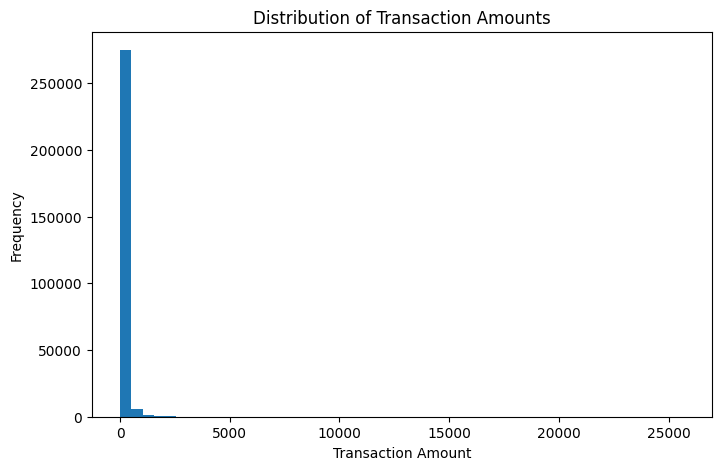

In [28]:
plt.figure(figsize=(8, 5))

plt.hist(df["Amount"], bins=50)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.savefig(f"{FIGURES_PATH}/transaction_amount_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Transaction Amounts by Class

Next, transaction amounts are compared between legitimate and fraudulent transactions. This helps determine whether fraud cases tend to occur at particular transaction sizes.

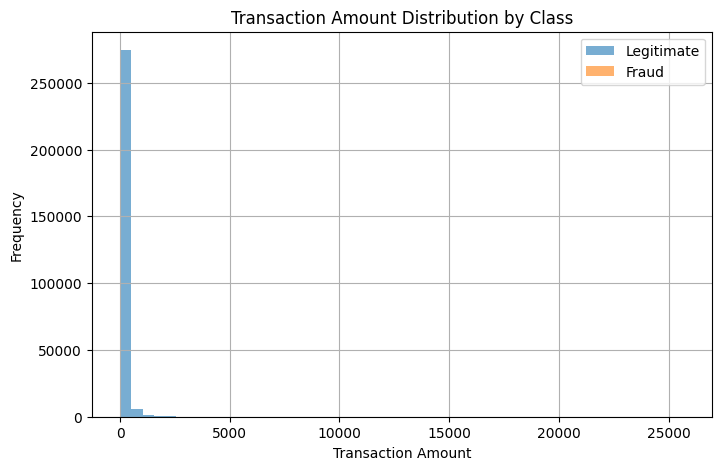

In [29]:
plt.figure(figsize=(8, 5))

df[df["Class"] == 0]["Amount"].hist(bins=50, alpha=0.6, label="Legitimate")
df[df["Class"] == 1]["Amount"].hist(bins=50, alpha=0.6, label="Fraud")

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.legend()

plt.savefig(f"{FIGURES_PATH}/transaction_amount_distribution_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0000,88.4136,250.3790,0.0000,5.6700,22.0000,77.4600,25691.1600
1,473.0000,123.8719,260.2110,0.0000,1.0000,9.8200,105.8900,2125.8700


### Transaction Time Distribution

The `Time` feature represents the number of seconds elapsed between the current transaction and the first transaction recorded in the dataset.

Examining this distribution helps understand how transactions are spread over time within the dataset.

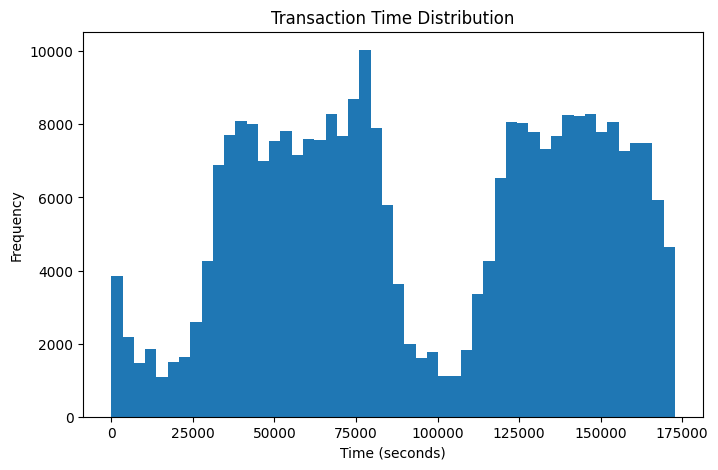

In [31]:
plt.figure(figsize=(8, 5))

plt.hist(df["Time"], bins=50)

plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")

plt.savefig(f"{FIGURES_PATH}/transaction_time_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Exploratory Insights

The exploratory analysis provides several insights into transaction behavior within the dataset.

The distribution of transaction amounts is **highly right-skewed**, indicating that the vast majority of transactions involve relatively small monetary values, while a small number of transactions correspond to very large amounts. This pattern is typical for financial transaction datasets, where everyday purchases dominate the activity and only a few transactions involve large sums.

When comparing transaction amounts between legitimate and fraudulent transactions, an interesting pattern emerges. Fraudulent transactions do **not consistently occur at higher transaction values**. Although the average fraud transaction amount (≈123.87) is slightly higher than that of legitimate transactions (≈88.41), the median fraud amount (≈9.82) is actually **lower than the median legitimate transaction amount (≈22.00)**. This suggests that fraudulent activity can occur across a wide range of transaction values and is not limited to unusually large purchases.

The time distribution of transactions shows that activity is spread across the full observation period and appears to exhibit **multiple peaks of activity**, which may correspond to daily transaction cycles. This indicates that transactions occur continuously over time rather than in isolated bursts.

Because the majority of variables in the dataset (V1–V28) are anonymized PCA components, their direct interpretation is limited. However, these variables still capture meaningful statistical patterns that can be exploited by machine learning models during classification.

Overall, the exploratory analysis suggests that **simple rules based on transaction amount alone would not be sufficient to reliably detect fraud**, reinforcing the need for machine learning models capable of identifying complex multivariate patterns.

## Data Preparation and Train-Test Split

Before building machine learning models, the dataset must be separated into a **feature matrix** and a **target variable**.

- **Features (X)** represent the input variables used by the model to make predictions.
- **Target (y)** represents the outcome variable indicating whether a transaction is fraudulent.

After defining these components, the dataset is divided into **training and testing subsets**. The training set is used to fit machine learning models, while the test set is reserved for evaluating model performance on unseen data.

Because fraud detection datasets are highly imbalanced, a **stratified split** is used to ensure that both the training and test sets maintain the same proportion of fraudulent and legitimate transactions.

In [32]:
# Define feature matrix and target variable
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (283726, 30)
Target vector shape: (283726,)


In [33]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (226980, 30)
Test set shape: (56746, 30)


In [34]:
print("Training set class distribution:")
display(y_train.value_counts(normalize=True) * 100)

print("\nTest set class distribution:")
display(y_test.value_counts(normalize=True) * 100)

Training set class distribution:


,proportion
Class,
0,99.8335
1,0.1665



Test set class distribution:


,proportion
Class,
0,99.8326
1,0.1674


### Dataset Preparation Summary

The dataset was separated into a **feature matrix (`X`)** containing the 30 predictor variables and a **target vector (`y`)** representing whether a transaction is fraudulent.

After removing duplicate records, the dataset contains **283,726 transactions**. These were divided into training and test subsets using an **80/20 stratified split**, resulting in:

- **Training set:** 226,980 transactions  
- **Test set:** 56,746 transactions  

Because the dataset is extremely imbalanced, stratification was applied to ensure that both subsets preserve the same proportion of fraudulent transactions present in the original data.

The resulting class distributions confirm that the imbalance has been preserved:

| Dataset | Legitimate | Fraud |
|--------|-----------|-------|
| Training Set | 99.8335% | 0.1665% |
| Test Set | 99.8326% | 0.1674% |

Maintaining this distribution is critical for reliable model evaluation. If the fraud ratio were distorted during splitting, model performance metrics could become misleading.

With the dataset now properly partitioned, the next step is to construct a **consistent evaluation framework** that will be used to compare multiple classification models throughout the analysis.

## Model Evaluation Framework

To ensure consistent and reliable comparison between different machine learning models, a reusable evaluation function is defined.

This function trains a model, generates predictions, and computes several performance metrics commonly used in imbalanced classification problems:

- **Accuracy** – overall proportion of correct predictions  
- **Precision** – proportion of predicted fraud cases that are actually fraud  
- **Recall** – proportion of real fraud cases successfully detected  
- **F1-score** – harmonic mean of precision and recall  
- **ROC-AUC** – ability of the model to rank fraud higher than legitimate transactions  
- **PR-AUC** – precision-recall area under the curve, particularly informative for imbalanced datasets

Using a standardized evaluation framework ensures that all models are assessed under the same conditions.

In [35]:
def evaluate_model(model, X_train, y_train, X_test, y_test, threshold=0.5, model_name="Model"):
    """
    Train a model and compute evaluation metrics.
    """

    # Train model
    model.fit(X_train, y_train)

    # Predicted probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # Apply classification threshold
    y_pred = (y_proba >= threshold).astype(int)

    # Compute metrics
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba)
    }

    return metrics, y_pred, y_proba

### Evaluation Function

The `evaluate_model()` function standardizes model assessment by automatically computing multiple evaluation metrics after training.

It returns:

- a **dictionary of performance metrics**
- predicted class labels
- predicted fraud probabilities

The predicted probabilities will later allow threshold tuning and the construction of ROC and precision-recall curves.

## Baseline Models

Before applying imbalance-aware techniques, it is important to establish baseline model performance. Baseline models provide a reference point that allows us to evaluate whether more advanced modeling approaches actually improve fraud detection.

In this section, three baseline classifiers are trained:

- **Dummy Classifier** – predicts the majority class for every transaction
- **Logistic Regression** – a commonly used linear classification model
- **Random Forest** – an ensemble model capable of capturing complex nonlinear patterns

These models will first be trained without any specific techniques designed to address class imbalance. Their performance will highlight the challenges posed by the extreme imbalance of fraudulent transactions.

### Dummy Classifier

The Dummy Classifier serves as a minimal baseline by always predicting the majority class. In highly imbalanced datasets, this approach can achieve very high accuracy despite failing to detect any fraud cases.

This baseline helps illustrate why accuracy alone is not a reliable metric for fraud detection problems.

In [36]:
dummy_model = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

dummy_metrics, dummy_pred, dummy_proba = evaluate_model(
    dummy_model,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Dummy Classifier"
)

dummy_metrics

{'Model': 'Dummy Classifier',
 'Accuracy': 0.9983258731892997,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1 Score': 0.0,
 'ROC-AUC': np.float64(0.5),
 'PR-AUC': np.float64(0.0016741268107003137)}

### Logistic Regression Baseline

Logistic Regression is a widely used linear classification algorithm that estimates the probability of an observation belonging to a particular class.

Because logistic regression is sensitive to feature scaling, a pipeline including **StandardScaler** is used to normalize the input variables before training the model.

In [37]:
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

log_reg_metrics, log_reg_pred, log_reg_proba = evaluate_model(
    log_reg_pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Logistic Regression"
)

log_reg_metrics

{'Model': 'Logistic Regression',
 'Accuracy': 0.9991188806259472,
 'Precision': 0.8461538461538461,
 'Recall': 0.5789473684210527,
 'F1 Score': 0.6875,
 'ROC-AUC': np.float64(0.9560466717268892),
 'PR-AUC': np.float64(0.6919665484964556)}

### Random Forest Baseline

Random Forest is an ensemble learning algorithm that constructs multiple decision trees and aggregates their predictions. It is capable of modeling complex nonlinear relationships and interactions between variables.

Because tree-based models are not sensitive to feature scaling, no preprocessing pipeline is required for this model.

In [38]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_metrics, rf_pred, rf_proba = evaluate_model(
    rf_model,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Random Forest"
)

rf_metrics

{'Model': 'Random Forest',
 'Accuracy': 0.9995065731505305,
 'Precision': 0.971830985915493,
 'Recall': 0.7263157894736842,
 'F1 Score': 0.8313253012048193,
 'ROC-AUC': np.float64(0.9239442050077622),
 'PR-AUC': np.float64(0.7876128638875491)}

### Baseline Model Observations

The baseline models provide an important reference point for evaluating fraud detection performance.

The **Dummy Classifier**, which predicts every transaction as legitimate, achieves an accuracy of **99.83%**. However, this model completely fails to detect fraudulent transactions, resulting in **zero precision, recall, and F1-score**. This demonstrates why **accuracy alone is not a meaningful metric** in highly imbalanced classification problems.

The **Logistic Regression** model performs substantially better. It successfully detects fraudulent transactions with a **recall of approximately 57.9%** while maintaining a high **precision of 84.6%**. This indicates that the model is able to identify many fraudulent transactions while producing relatively few false positives. The model also achieves a strong **ROC-AUC score of 0.956**, suggesting good separation between fraud and legitimate transactions.

The **Random Forest** model provides the strongest baseline performance. It achieves a **precision of 97.2%** and a **recall of 72.6%**, resulting in an **F1-score of approximately 0.83**. This indicates that the model is capable of detecting a large proportion of fraudulent transactions while keeping false positives very low.

These results highlight two key observations:

1. **Naïve models can achieve very high accuracy while being completely ineffective**, emphasizing the importance of precision and recall in fraud detection.
2. **More sophisticated models such as Random Forest can capture complex patterns in the data**, improving the detection of rare fraud events.

Despite these promising baseline results, the extreme class imbalance still poses a challenge. The next stage of the analysis will introduce **imbalance-aware modeling techniques**, including class weighting and synthetic oversampling (SMOTE), to further improve fraud detection performance.

## Imbalance-Aware Models

The extreme class imbalance present in fraud detection datasets can make it difficult for machine learning models to correctly identify fraudulent transactions.

To address this challenge, several imbalance-aware modeling strategies are explored:

- **Class weighting** – increases the importance of minority-class observations during training
- **SMOTE (Synthetic Minority Oversampling Technique)** – generates synthetic fraud samples to balance the dataset
- **Balanced ensemble methods** – modify the training process to handle imbalanced data more effectively

These techniques aim to improve the model’s ability to detect rare fraud cases while maintaining reasonable precision.

### Logistic Regression with Class Weights

One simple approach to handling class imbalance is to assign higher importance to minority-class observations during training. This is achieved using the `class_weight="balanced"` parameter, which automatically adjusts the weight of each class based on its frequency in the dataset.

In [39]:
log_reg_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

log_reg_bal_metrics, log_reg_bal_pred, log_reg_bal_proba = evaluate_model(
    log_reg_balanced,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Logistic Regression (Balanced)"
)

log_reg_bal_metrics

{'Model': 'Logistic Regression (Balanced)',
 'Accuracy': 0.9753110351390406,
 'Precision': 0.05638586956521739,
 'Recall': 0.8736842105263158,
 'F1 Score': 0.10593490746649649,
 'ROC-AUC': np.float64(0.9656548079701293),
 'PR-AUC': np.float64(0.6719244530518995)}

### Random Forest with Class Weights

Random Forest can also incorporate class weighting, allowing the model to penalize misclassification of fraudulent transactions more heavily during training.

In [40]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_bal_metrics, rf_bal_pred, rf_bal_proba = evaluate_model(
    rf_balanced,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Random Forest (Balanced)"
)

rf_bal_metrics

{'Model': 'Random Forest (Balanced)',
 'Accuracy': 0.9994713283755683,
 'Precision': 0.9710144927536232,
 'Recall': 0.7052631578947368,
 'F1 Score': 0.8170731707317073,
 'ROC-AUC': np.float64(0.9246086611561649),
 'PR-AUC': np.float64(0.7960116616802263)}

### SMOTE with Logistic Regression

SMOTE (Synthetic Minority Oversampling Technique) generates artificial minority-class examples by interpolating between existing fraud observations. This helps balance the training dataset and allows the model to learn patterns associated with fraud more effectively.

In [41]:
smote_log_reg = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

smote_log_metrics, smote_log_pred, smote_log_proba = evaluate_model(
    smote_log_reg,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="SMOTE + Logistic Regression"
)

smote_log_metrics

{'Model': 'SMOTE + Logistic Regression',
 'Accuracy': 0.99115356148451,
 'Precision': 0.14235500878734622,
 'Recall': 0.8526315789473684,
 'F1 Score': 0.24397590361445784,
 'ROC-AUC': np.float64(0.9629093740157882),
 'PR-AUC': np.float64(0.7027249941620093)}

### SMOTE with Random Forest

Combining SMOTE with Random Forest allows the model to learn from a more balanced training dataset while still capturing complex nonlinear patterns in the data.

In [42]:
smote_rf = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

smote_rf_metrics, smote_rf_pred, smote_rf_proba = evaluate_model(
    smote_rf,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="SMOTE + Random Forest"
)

smote_rf_metrics

{'Model': 'SMOTE + Random Forest',
 'Accuracy': 0.9994537059880872,
 'Precision': 0.8902439024390244,
 'Recall': 0.7684210526315789,
 'F1 Score': 0.8248587570621468,
 'ROC-AUC': np.float64(0.9608938941942773),
 'PR-AUC': np.float64(0.804139304026483)}

### Balanced Random Forest

Balanced Random Forest is an ensemble method specifically designed for imbalanced datasets. It modifies the standard Random Forest training process by balancing the class distribution within each bootstrap sample used to build the individual trees.

In [43]:
brf_model = BalancedRandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

brf_metrics, brf_pred, brf_proba = evaluate_model(
    brf_model,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Balanced Random Forest"
)

brf_metrics

{'Model': 'Balanced Random Forest',
 'Accuracy': 0.9875938392133367,
 'Precision': 0.10299869621903521,
 'Recall': 0.8315789473684211,
 'F1 Score': 0.18329466357308585,
 'ROC-AUC': np.float64(0.971581678773729),
 'PR-AUC': np.float64(0.7195548032231309)}

### Imbalance-Aware Model Observations

The imbalance-aware models were designed to improve the detection of fraudulent transactions by either increasing the importance of the minority class or by balancing the training dataset.

The **Logistic Regression with class weighting** significantly increases the model’s ability to detect fraud, achieving a **recall of 87.37%**, meaning that most fraudulent transactions are successfully identified. However, this improvement comes at the cost of precision (≈5.6%), indicating that the model generates many false positives. This behavior is typical when models are heavily biased toward detecting the minority class.

The **balanced Random Forest** maintains strong recall (≈83.16%) but also suffers from low precision, which again reflects the trade-off between aggressively detecting fraud and limiting false alarms.

The **SMOTE-based models** show more balanced behavior. In particular, **SMOTE combined with Random Forest** achieves one of the best overall trade-offs, with:

- **Precision:** 89.0%  
- **Recall:** 76.8%  
- **F1-score:** 0.825  
- **PR-AUC:** ≈0.804  

This indicates that the model is able to detect a substantial portion of fraudulent transactions while maintaining relatively low false-positive rates.

The **Random Forest with class weighting** also performs strongly, achieving **97.1% precision and 70.5% recall**, resulting in an F1-score of approximately **0.817**.

Overall, these results highlight an important principle in fraud detection: **improving recall often comes at the expense of precision**. Models that aggressively detect fraud may capture more fraudulent transactions but may also produce more false alarms.

The next step is to **combine all model results into a single comparison table**, which will allow a clearer evaluation of the trade-offs between the different modeling strategies.

## Model Performance Comparison

After training both baseline models and imbalance-aware models, their performance can now be compared in a unified evaluation table.

This comparison highlights how different modeling strategies affect fraud detection performance, particularly in terms of precision, recall, and F1-score. Because the dataset is extremely imbalanced, special attention is given to **PR-AUC**, which provides a more informative evaluation metric for rare-event classification problems.

Sorting the results by PR-AUC allows us to quickly identify the models that best balance fraud detection capability with false-positive control.

In [44]:
# Combine results from all models
results = pd.DataFrame([
    dummy_metrics,
    log_reg_metrics,
    rf_metrics,
    log_reg_bal_metrics,
    rf_bal_metrics,
    smote_log_metrics,
    smote_rf_metrics,
    brf_metrics
])

# Sort by PR-AUC (most informative metric for imbalanced data)
results = results.sort_values(by="PR-AUC", ascending=False).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,SMOTE + Random Forest,0.9995,0.8902,0.7684,0.8249,0.9609,0.8041
1,Random Forest (Balanced),0.9995,0.9710,0.7053,0.8171,0.9246,0.7960
2,Random Forest,0.9995,0.9718,0.7263,0.8313,0.9239,0.7876
3,Balanced Random Forest,0.9876,0.1030,0.8316,0.1833,0.9716,0.7196
4,SMOTE + Logistic Regression,0.9912,0.1424,0.8526,0.2440,0.9629,0.7027
5,Logistic Regression,0.9991,0.8462,0.5789,0.6875,0.9560,0.6920
6,Logistic Regression (Balanced),0.9753,0.0564,0.8737,0.1059,0.9657,0.6719
7,Dummy Classifier,0.9983,0.0000,0.0000,0.0000,0.5000,0.0017


In [45]:
results_rounded = results.copy()

for col in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"]:
    results_rounded[col] = results_rounded[col].round(4)

results_rounded

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,SMOTE + Random Forest,0.9995,0.8902,0.7684,0.8249,0.9609,0.8041
1,Random Forest (Balanced),0.9995,0.9710,0.7053,0.8171,0.9246,0.7960
2,Random Forest,0.9995,0.9718,0.7263,0.8313,0.9239,0.7876
3,Balanced Random Forest,0.9876,0.1030,0.8316,0.1833,0.9716,0.7196
4,SMOTE + Logistic Regression,0.9912,0.1424,0.8526,0.2440,0.9629,0.7027
5,Logistic Regression,0.9991,0.8462,0.5789,0.6875,0.9560,0.6920
6,Logistic Regression (Balanced),0.9753,0.0564,0.8737,0.1059,0.9657,0.6719
7,Dummy Classifier,0.9983,0.0000,0.0000,0.0000,0.5000,0.0017


### Model Comparison Insights

The comparison table summarizes the performance of all evaluated models across multiple evaluation metrics. Because the dataset is extremely imbalanced, **PR-AUC** is used as the primary ranking metric since it focuses on the model's ability to correctly identify the minority (fraud) class.

Several key observations emerge from the results:

**SMOTE + Random Forest** achieves the highest PR-AUC (≈0.804) and provides one of the best overall balances between precision and recall. With **89.0% precision and 76.8% recall**, this model successfully detects a large proportion of fraudulent transactions while maintaining relatively low false-positive rates.

The **baseline Random Forest model** also performs extremely well, achieving the highest F1-score (≈0.831) with **97.2% precision and 72.6% recall**. This indicates that ensemble tree models are particularly effective for this dataset even without aggressive imbalance correction.

The **Random Forest with class weighting** produces very similar results, demonstrating that tree-based models are inherently robust to moderate class imbalance.

Models that strongly prioritize recall, such as **Logistic Regression (Balanced)** and **Balanced Random Forest**, detect a very high proportion of fraudulent transactions but generate a large number of false positives. This behavior may still be desirable in real-world fraud detection systems where maximizing fraud detection is more important than minimizing manual review effort.

Finally, the **Dummy Classifier** achieves extremely high accuracy (≈99.83%) while completely failing to detect any fraud cases. This confirms that **accuracy alone is not an appropriate metric for evaluating highly imbalanced classification problems**.

Overall, the results suggest that **ensemble tree-based methods combined with imbalance-aware techniques provide the most effective fraud detection performance for this dataset**.

## Visual Model Evaluation

While numerical metrics provide a useful summary of model performance, visual diagnostics can offer deeper insight into how models behave in practice.

In this section, several visualization techniques are used to analyze the top-performing models:

- **Confusion matrices** to show the number of correctly and incorrectly classified transactions
- **ROC curves** to compare the ranking ability of different models
- **Precision–Recall curves** to evaluate model performance specifically for the minority (fraud) class

Because fraud detection is an imbalanced classification problem, the **precision–recall curve is particularly informative**, as it focuses directly on the model's ability to detect fraudulent transactions.

### Confusion Matrices for Top Models

Confusion matrices provide a detailed view of classification outcomes by showing:

- **True Negatives (TN)** – legitimate transactions correctly classified
- **False Positives (FP)** – legitimate transactions incorrectly flagged as fraud
- **False Negatives (FN)** – fraudulent transactions missed by the model
- **True Positives (TP)** – fraudulent transactions correctly detected

Examining these values helps understand the real-world implications of each model’s predictions.

In [46]:
# Select top 3 models from comparison table
top_models = results["Model"].head(3).tolist()

top_models

['SMOTE + Random Forest', 'Random Forest (Balanced)', 'Random Forest']

In [47]:
model_predictions = {
    "Dummy Classifier": dummy_pred,
    "Logistic Regression": log_reg_pred,
    "Random Forest": rf_pred,
    "Logistic Regression (Balanced)": log_reg_bal_pred,
    "Random Forest (Balanced)": rf_bal_pred,
    "SMOTE + Logistic Regression": smote_log_pred,
    "SMOTE + Random Forest": smote_rf_pred,
    "Balanced Random Forest": brf_pred
}

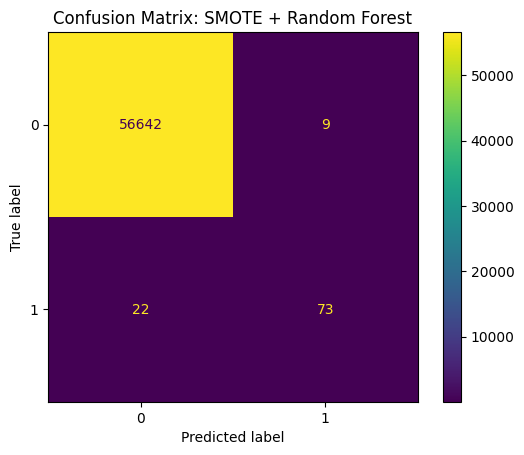

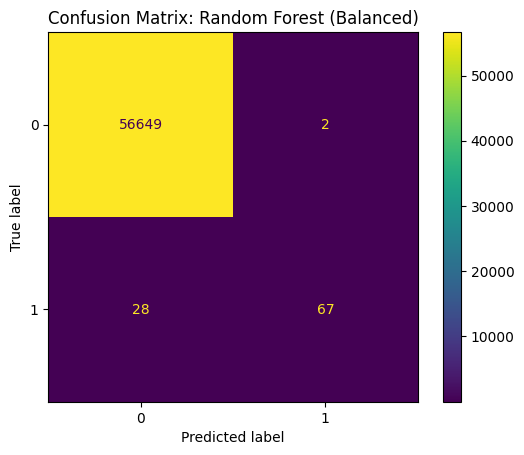

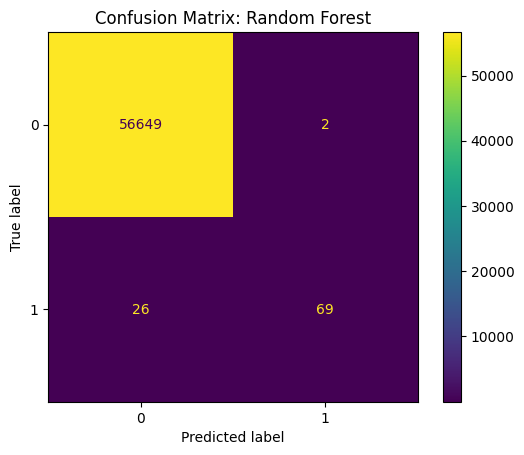

In [48]:
confusion_matrix_filenames = {
    "SMOTE + Random Forest": "confusion_matrix_smote_random_forest.png",
    "Random Forest (Balanced)": "confusion_matrix_random_forest_balanced.png",
    "Random Forest": "confusion_matrix_random_forest.png"
}

for model_name in top_models:
    cm = confusion_matrix(y_test, model_predictions[model_name])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title(f"Confusion Matrix: {model_name}")

    filename = confusion_matrix_filenames.get(
        model_name,
        f"confusion_matrix_{model_name.lower().replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '')}.png"
    )
    plt.savefig(f"{FIGURES_PATH}/{filename}", dpi=300, bbox_inches="tight")
    plt.show()

### ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve illustrates the relationship between the **true positive rate (recall)** and the **false positive rate** across different classification thresholds.

The area under the ROC curve (ROC-AUC) measures the model’s ability to distinguish between fraudulent and legitimate transactions. Higher values indicate better discrimination.

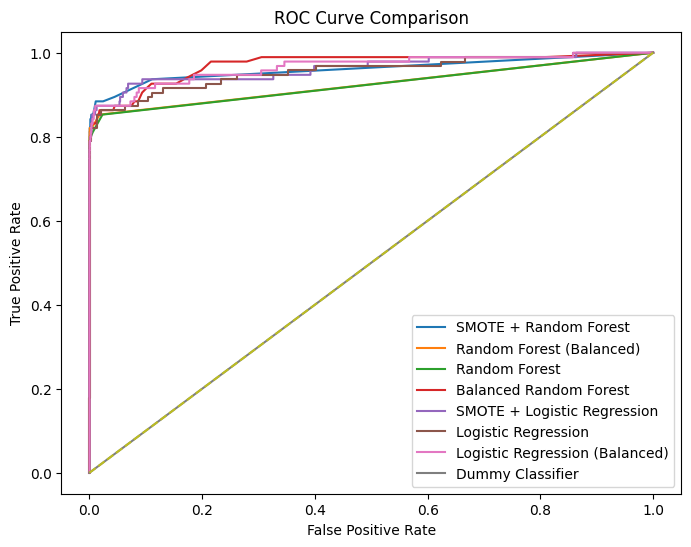

In [49]:
model_probabilities = {
    "Dummy Classifier": dummy_proba,
    "Logistic Regression": log_reg_proba,
    "Random Forest": rf_proba,
    "Logistic Regression (Balanced)": log_reg_bal_proba,
    "Random Forest (Balanced)": rf_bal_proba,
    "SMOTE + Logistic Regression": smote_log_proba,
    "SMOTE + Random Forest": smote_rf_proba,
    "Balanced Random Forest": brf_proba
}

plt.figure(figsize=(8, 6))

for model_name in results["Model"]:
    fpr, tpr, _ = roc_curve(y_test, model_probabilities[model_name])
    plt.plot(fpr, tpr, label=model_name)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig(f"{FIGURES_PATH}/roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Precision–Recall Curve Comparison

In highly imbalanced classification problems such as fraud detection, the **precision–recall curve** often provides a more meaningful evaluation than the ROC curve.

This curve shows how precision and recall change as the classification threshold varies, helping identify models that maintain high fraud detection while limiting false positives.

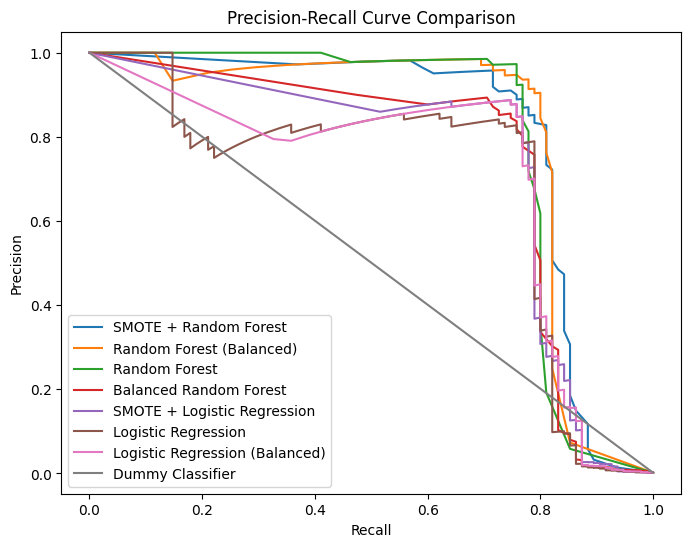

In [50]:
plt.figure(figsize=(8, 6))

for model_name in results["Model"]:
    precision, recall, _ = precision_recall_curve(y_test, model_probabilities[model_name])
    plt.plot(recall, precision, label=model_name)

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.savefig(f"{FIGURES_PATH}/precision_recall_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Visual Performance Insights

The visual evaluation of the top-performing models provides additional insight into their behavior when detecting fraudulent transactions.

The confusion matrices reveal that all three top models successfully detect a large proportion of fraudulent transactions while maintaining extremely low false-positive rates. For example, the **SMOTE + Random Forest** model correctly identifies **73 fraudulent transactions** while missing **22 cases**, demonstrating strong recall while keeping the number of incorrectly flagged legitimate transactions very small.

Similarly, the **Random Forest** and **Random Forest (Balanced)** models show strong detection capability, correctly identifying the majority of fraud cases with very few false alarms. These results confirm the strong performance observed in the numerical evaluation metrics.

The ROC curves show that most models achieve very high true positive rates with relatively low false positive rates, which explains the strong ROC-AUC scores observed earlier. The curves of the top-performing models lie close to the upper-left corner of the plot, indicating strong discriminative ability.

The **precision–recall curves provide the most meaningful comparison** for this imbalanced classification problem. The top-performing models maintain high precision even at relatively high recall levels, demonstrating their ability to detect fraudulent transactions without generating excessive false positives.

Overall, the visual diagnostics confirm the earlier numerical results: **Random Forest-based models provide the most reliable fraud detection performance for this dataset**, particularly when combined with imbalance-aware techniques such as SMOTE.

## Threshold Optimization

Most classification models use a default probability threshold of **0.5** to convert predicted probabilities into class labels. However, this threshold may not be optimal for fraud detection problems.

In highly imbalanced datasets, adjusting the classification threshold can significantly change the trade-off between **precision** and **recall**.

Lower thresholds may detect more fraudulent transactions but produce more false positives, while higher thresholds may reduce false alarms but miss more fraud cases.

In this section, different classification thresholds are evaluated to identify an operating point that provides the best balance between fraud detection and false-positive control.

### Selecting the Best Model for Threshold Analysis

Based on the model comparison results, the model with the highest PR-AUC is selected for threshold optimization. This model provides the strongest baseline performance for detecting fraudulent transactions.

In [51]:
best_model_name = results.loc[0, "Model"]

print("Best model based on PR-AUC:", best_model_name)

Best model based on PR-AUC: SMOTE + Random Forest


In [52]:
best_proba = model_probabilities[best_model_name]

### Evaluating Different Classification Thresholds

To analyze the effect of threshold selection, model predictions are evaluated across a range of probability thresholds. For each threshold, precision, recall, and F1-score are calculated.

In [53]:
thresholds = np.arange(0.1, 1.0, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_thresh = (best_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_thresh, zero_division=0),
        "Recall": recall_score(y_test, y_pred_thresh, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_thresh, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.1000,0.3068,0.8526,0.4513
1,0.1500,0.5065,0.8211,0.6265
2,0.2000,0.6964,0.8211,0.7536
3,0.2500,0.7938,0.8105,0.8021
4,0.3000,0.8427,0.7895,0.8152
5,0.3500,0.8523,0.7895,0.8197
6,0.4000,0.8605,0.7789,0.8177
7,0.4500,0.8706,0.7789,0.8222
8,0.5000,0.8902,0.7684,0.8249
9,0.5500,0.9000,0.7579,0.8229


In [54]:
best_threshold_row = threshold_df.sort_values(by="F1 Score", ascending=False).iloc[0]

best_threshold = best_threshold_row["Threshold"]

print("Best threshold based on F1-score:", best_threshold)

best_threshold_row

Best threshold based on F1-score: 0.5000000000000001


,8
Threshold,0.5000
Precision,0.8902
Recall,0.7684
F1 Score,0.8249


### Threshold Performance Visualization

The following plot shows how precision, recall, and F1-score change as the classification threshold varies.

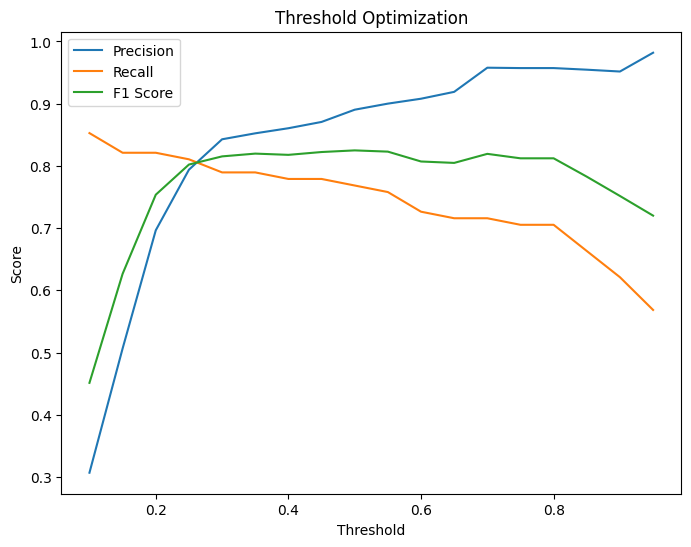

In [55]:
plt.figure(figsize=(8, 6))

plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1 Score"], label="F1 Score")

plt.title("Threshold Optimization")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()

plt.savefig(f"{FIGURES_PATH}/threshold_optimization.png", dpi=300, bbox_inches="tight")
plt.show()

### Final Predictions Using the Optimized Threshold

Using the selected threshold, the model predictions are recalculated to evaluate the final fraud detection performance.

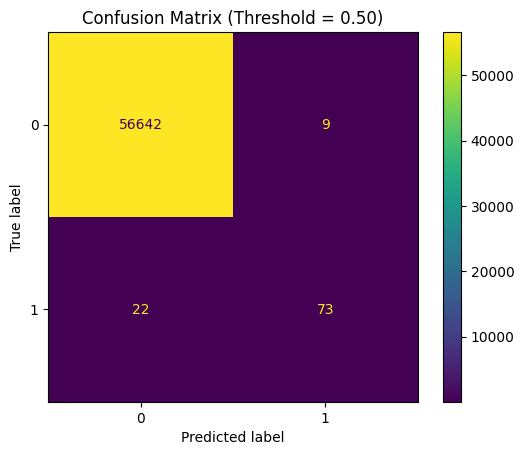

In [56]:
final_pred = (best_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title(f"Confusion Matrix (Threshold = {best_threshold:.2f})")

plt.savefig(f"{FIGURES_PATH}/confusion_matrix_optimized_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.77      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



### Threshold Optimization Insights

The threshold optimization analysis evaluates how different classification thresholds affect fraud detection performance for the selected best-performing model (**SMOTE + Random Forest**).

The results show a clear trade-off between **precision** and **recall**:

- Lower thresholds increase recall by detecting more fraudulent transactions but generate more false positives.
- Higher thresholds increase precision by reducing false alarms but may miss more fraud cases.

Across the evaluated thresholds, the **highest F1-score (≈0.825)** is achieved at a threshold of **0.50**, which provides a balanced trade-off between fraud detection capability and false-positive control.

At this threshold the model achieves:

- **Precision:** 89.0%
- **Recall:** 76.8%
- **F1-score:** 0.825

The confusion matrix shows that the model correctly identifies **73 fraudulent transactions** while missing **22 fraud cases**, and incorrectly flags only **9 legitimate transactions** as fraud.

These results demonstrate that the selected model is capable of detecting the majority of fraudulent transactions while maintaining extremely low false-positive rates.

Importantly, the optimal threshold depends on operational priorities. In real-world fraud detection systems:

- A **lower threshold** may be chosen if maximizing fraud detection is critical.
- A **higher threshold** may be chosen if minimizing false alarms is more important.

This threshold analysis highlights how machine learning models can be tuned to align with real-world operational objectives.

## Final Model Recommendation

This project explored the challenge of detecting fraudulent credit card transactions within a highly imbalanced dataset. Because fraudulent transactions represent only a very small fraction of all observations, traditional evaluation metrics such as accuracy are insufficient for assessing model performance.

### Summary of Findings

Several modeling strategies were evaluated, including baseline classifiers and imbalance-aware approaches. The results indicate that **ensemble tree-based models consistently outperform linear models** in this dataset.

Among all evaluated models, **SMOTE combined with Random Forest** achieved the strongest overall performance according to the PR-AUC metric, which is particularly appropriate for imbalanced classification problems.

### Final Model Performance

Using the optimized classification threshold of **0.50**, the selected model achieves the following performance on the test set:

- **Precision:** 89.0%
- **Recall:** 76.8%
- **F1-score:** 0.825
- **PR-AUC:** ≈0.804

The confusion matrix shows that the model correctly detects **73 fraudulent transactions** while missing **22 fraud cases**, and incorrectly flags only **9 legitimate transactions** as fraudulent.

### Practical Implications

These results demonstrate that the model is capable of detecting the majority of fraudulent transactions while maintaining extremely low false-positive rates. Such performance is desirable in fraud detection systems where excessive false alarms can overwhelm manual investigation processes.

In real-world deployments, the classification threshold could be adjusted depending on operational priorities:

- Lower thresholds may be used to **maximize fraud detection (higher recall)**.
- Higher thresholds may be used to **reduce false positives (higher precision)**.

### Key Takeaways

This project highlights several important principles in machine learning for imbalanced classification:

- **Accuracy alone is misleading in highly imbalanced datasets**
- **Precision, recall, and PR-AUC provide more meaningful evaluation metrics**
- **Imbalance-aware techniques such as SMOTE can improve fraud detection performance**
- **Threshold optimization allows models to be tuned for operational objectives**

Overall, the analysis demonstrates that **Random Forest–based models combined with imbalance-aware techniques provide an effective approach for detecting fraudulent financial transactions.**